# **Gaussian Naive Bayes from Scratch**

## 0.ライブラリのインポートとデータの生成

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

X, y = make_blobs(n_samples=300, centers=3, cluster_std=3.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 1.アルゴリズム

ベイズの定理をベースに、各クラスの確率を計算して分類するアルゴリズム。

特徴量が互いに独立だと仮定することで計算を大幅に簡略化している。

### 1.1.ベイズの定理

新しいデータに対して、各クラスCである確率を計算する。

P(C | X) = P(X | C)P(C) / P(X)

P(X)     : 周辺尤度  
P(C)     : 事前確率  
P(X | C) : 尤度  
P(C | X) : 事後確率

### 1.2.ナイーブの仮定

各特徴量が独立だと仮定することで、尤度を特徴量ごとの確率の積に分解できる。

$$P(X|C) = \prod_{i=1}^{n} P(x_i|C)$$

### 1.3.ガウス分布

各特徴量の確率密度関数に正規分布を仮定する。

$$P(x_i|C) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)$$

In [14]:
def gaussian(x, mean, std):
  return (1 / np.sqrt(2 * np.pi * std**2)) * np.exp(-((x - mean)**2) / (2 * std**2))

def fit(X, y):
  classes = np.unique(y)
  priors = {}
  means = {}
  stds = {}

  for c in classes:
    X_c = X[y == c]
    priors[c] = len(X_c) / len(X)
    means[c] = np.mean(X_c, axis=0)
    stds[c] = np.std(X_c, axis=0)

  return priors, means, stds

def predict(X, priors, means, stds):
  predictions = []

  for x in X:
    class_probs = {}
    for c in priors:
      likelihood = np.prod(gaussian(x, means[c], stds[c]))
      class_probs[c] = priors[c] * likelihood

    predictions.append(max(class_probs, key=class_probs.get))

  return np.array(predictions)

## 2.モデルの可視化

### 2.1.決定境界

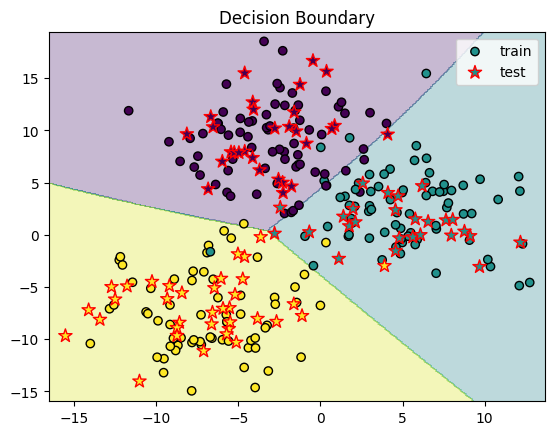

In [15]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
grid = np.c_[xx.ravel(), yy.ravel()]
priors, means, stds = fit(X_train, y_train)
Z = predict(grid, priors, means, stds)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', label='train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='r', marker='*', s=100, label='test')
plt.title("Decision Boundary")
plt.legend()
plt.show()

### 2.2.ガウス分布

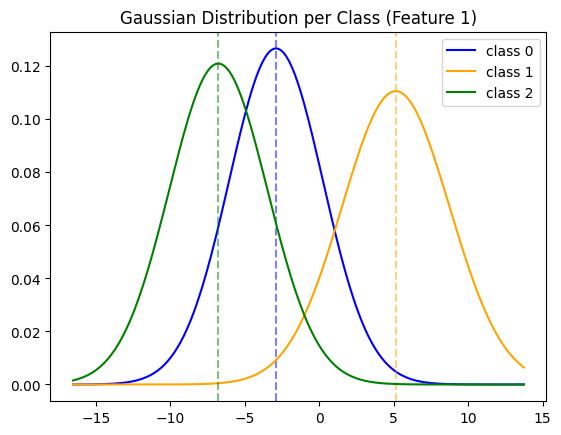

In [16]:
colors = ['blue', 'orange', 'green']
x_range = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
for c in priors:
  dist = gaussian(x_range, means[c][0], stds[c][0])
  plt.plot(x_range, dist, label=f'class {c}', color=colors[c])
  plt.axvline(means[c][0], linestyle='--', color=colors[c], alpha=0.5)
plt.title("Gaussian Distribution per Class (Feature 1)")
plt.legend()
plt.show()

## 3.検証

### 3.1.精度

In [17]:
priors, means, stds = fit(X_train, y_train)
y_pred = predict(X_test, priors, means, stds)

accuracy = np.sum(y_pred == y_test) / len(y_test)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.967


### 3.2.クラスごとの精度

In [18]:
for c in np.unique(y_test):
  mask = y_test == c
  class_acc = np.sum(y_pred[mask] == y_test[mask]) / np.sum(mask)
  print(f"Class {c} Accuracy: {class_acc:.3f}")

Class 0 Accuracy: 0.966
Class 1 Accuracy: 0.962
Class 2 Accuracy: 0.971


### 3.3.精度比較

データの標準偏差が大きくなる(cluster_stdが大きくなる)ほど、クラス間の重なりが増えて精度が低下する。ガウシアンナイーブベイズはクラスごとにガウス分布を当てはめるため、分布が重なると判断が難しくなる。

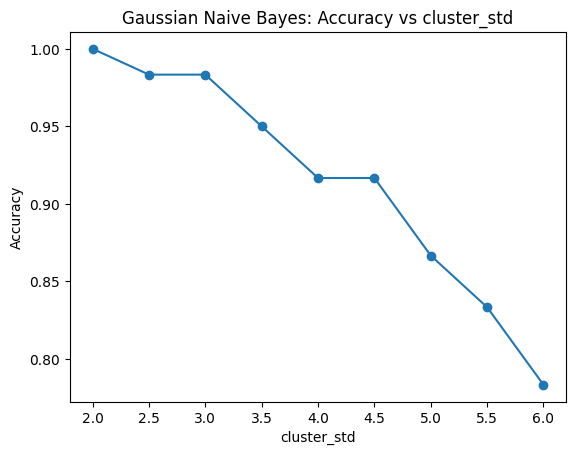

In [32]:
std_values = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
accuracies = []

for std_val in std_values:
  X_tmp, y_tmp = make_blobs(n_samples=300, centers=3, cluster_std=std_val, random_state=42)
  X_tmp_train, X_tmp_test, y_tmp_train, y_tmp_test = train_test_split(X_tmp, y_tmp, test_size=0.2, random_state=42)
  p, m, s = fit(X_tmp_train, y_tmp_train)
  y_tmp_pred = predict(X_tmp_test, p, m, s)
  acc = np.sum(y_tmp_pred == y_tmp_test) / len(y_tmp_test)
  accuracies.append(acc)

plt.plot(std_values, accuracies, marker='o')
plt.xlabel("cluster_std")
plt.ylabel("Accuracy")
plt.title("Gaussian Naive Bayes: Accuracy vs cluster_std")
plt.show()

## 4.ナイーブの仮定の検証

ナイーブベイズは特徴量が独立だと仮定しているため、この仮定が崩れたとき、精度にどのような影響を与えるかを検証する。

### 4.1.相関ありデータの生成

In [27]:
mean1 = [1, 1]
mean2 = [-1, -1]
cov = [[1, 0.7], [0.7, 1]]

X_corr1 = np.random.multivariate_normal(mean1, cov, 150)
X_corr2 = np.random.multivariate_normal(mean2, cov, 150)
X_corr = np.vstack([X_corr1, X_corr2])
y_corr = np.array([0]*150 + [1]*150)

X_corr_train, X_corr_test, y_corr_train, y_corr_test = train_test_split(X_corr, y_corr, test_size=0.2, random_state=42)

### 4.2.決定境界の可視化

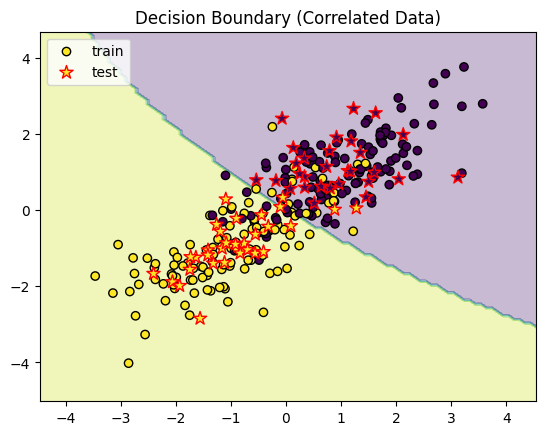

In [28]:
x_min, x_max = X_corr[:, 0].min() - 1, X_corr[:, 0].max() + 1
y_min, y_max = X_corr[:, 1].min() - 1, X_corr[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
grid = np.c_[xx.ravel(), yy.ravel()]
priors_corr, means_corr, stds_corr = fit(X_corr_train, y_corr_train)
Z_corr = predict(grid, priors_corr, means_corr, stds_corr)
Z_corr = Z_corr.reshape(xx.shape)

plt.contourf(xx, yy, Z_corr, alpha=0.3)
plt.scatter(X_corr_train[:, 0], X_corr_train[:, 1], c=y_corr_train, edgecolors='k', label='train')
plt.scatter(X_corr_test[:, 0], X_corr_test[:, 1], c=y_corr_test, edgecolors='r', marker='*', s=100, label='test')
plt.title("Decision Boundary (Correlated Data)")
plt.legend()
plt.show()

### 4.3.精度

In [29]:
priors_corr, means_corr, stds_corr = fit(X_corr_train, y_corr_train)
y_corr_pred = predict(X_corr_test, priors_corr, means_corr, stds_corr)
acc_corr = np.sum(y_corr_pred == y_corr_test) / len(y_corr_test)
print(f"\nCorrelated Data Accuracy: {acc_corr:.3f}")


Correlated Data Accuracy: 0.950
